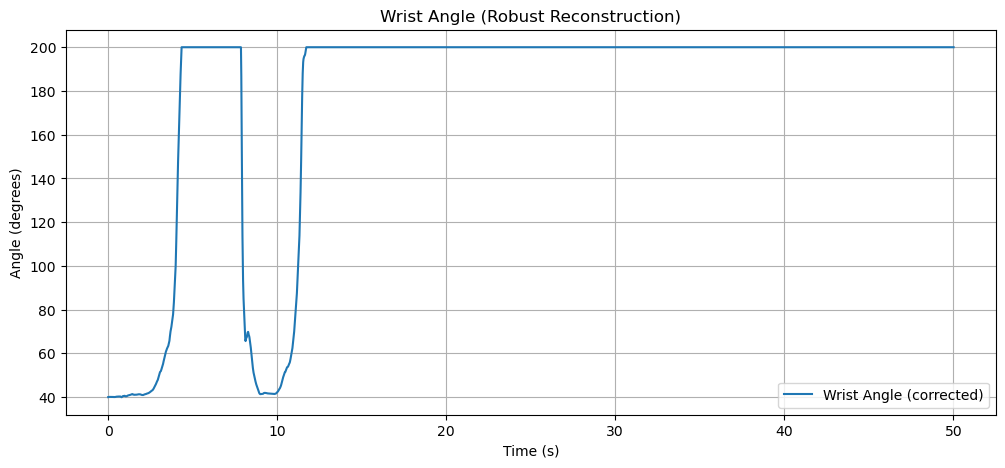

===== CHECK =====
Min angle: 39.94861325483116
Max angle: 200.0
Mean angle: 177.4298221058448


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER PARAMETER (MODIFY HERE)
# ==========================================================

# 👉 Put your manual baseline (from video analysis here)
BASELINE_ANGLE = 40  # <-- change this for each file

# ==========================================================
# FUNCTION: ROBUST QUATERNION → ANGLE
# ==========================================================

def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Robust conversion from quaternion to anatomical angle.

    Fixes:
    - Prevents unwrap drift
    - Keeps physiological angle range
    """

    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_raw)

    # ---------- STEP 3: REMOVE DISCONTINUITIES ----------
    angle_corrected = angle_deg.copy()

    for i in range(1, len(angle_corrected)):
        diff = angle_corrected[i] - angle_corrected[i-1]

        if diff > 180:
            angle_corrected[i:] -= 360
        elif diff < -180:
            angle_corrected[i:] += 360

    # ---------- STEP 4: NORMALIZATION ----------
    angle_zeroed = angle_corrected - angle_corrected[0]

    # Ensure correct direction
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY BASELINE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # ---------- STEP 6: CLIP TO PHYSIOLOGICAL RANGE ----------
    angle_anatomical = np.clip(angle_anatomical, 0, 200)

    # ---------- OUTPUT ----------
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles

# ==========================================================
# APPLY TO YOUR DATA
# ==========================================================

# 👉 Get wrist data from previous step
file = "Data_Lo_D_1.csv"
df_wrist = results[file]["wrist"]

# Convert quaternion → angle
df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, BASELINE_ANGLE)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(
    df_wrist_angles["time"],
    df_wrist_angles["angle"],
    label="Wrist Angle (corrected)",
)

plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Wrist Angle (Robust Reconstruction)")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# DEBUG CHECK
# ==========================================================

print("===== CHECK =====")
print("Min angle:", df_wrist_angles["angle"].min())
print("Max angle:", df_wrist_angles["angle"].max())
print("Mean angle:", df_wrist_angles["angle"].mean())